# 基础堆叠面积图

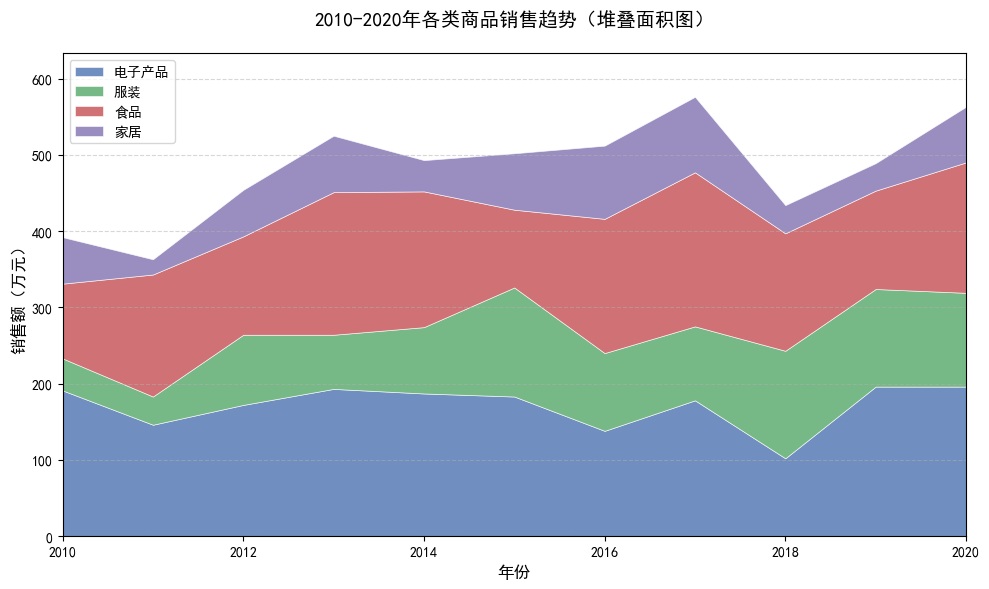

<Figure size 640x480 with 0 Axes>

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体（解决中文显示问题）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 示例数据准备
years = np.arange(2010, 2021)  # x轴数据：2010-2020年
categories = ['电子产品', '服装', '食品', '家居']  # 分类名称

# 生成随机数据（4个分类，11年数据）
data = np.array([
    np.random.randint(50, 200, size=len(years)),  # 电子产品
    np.random.randint(30, 150, size=len(years)),  # 服装
    np.random.randint(80, 250, size=len(years)),  # 食品
    np.random.randint(20, 100, size=len(years))   # 家居
])

# 创建画布和坐标轴
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制堆叠面积图
ax.stackplot(years, data, 
             labels=categories,  # 设置图例标签
             colors=['#4C72B0', '#55A868', '#C44E52', '#8172B2'],  # 自定义颜色
             alpha=0.8,  # 设置透明度
             edgecolor='white',  # 边界线颜色
             linewidth=0.5)  # 边界线宽度

# 添加图表元素
ax.set_title('2010-2020年各类商品销售趋势（堆叠面积图）', pad=20, fontsize=14)
ax.set_xlabel('年份', fontsize=12)
ax.set_ylabel('销售额（万元）', fontsize=12)
ax.legend(loc='upper left', fontsize=10)  # 图例位置

# 设置坐标轴范围
ax.set_xlim(2010, 2020)
ax.set_ylim(0, np.sum(data, axis=0).max() * 1.1)  # y轴自动适应数据范围

# 添加网格线
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 优化布局
plt.tight_layout()

# 显示图表
plt.show()

# 保存图表（可选）
plt.savefig('stacked_area_chart.png', dpi=400, bbox_inches='tight')

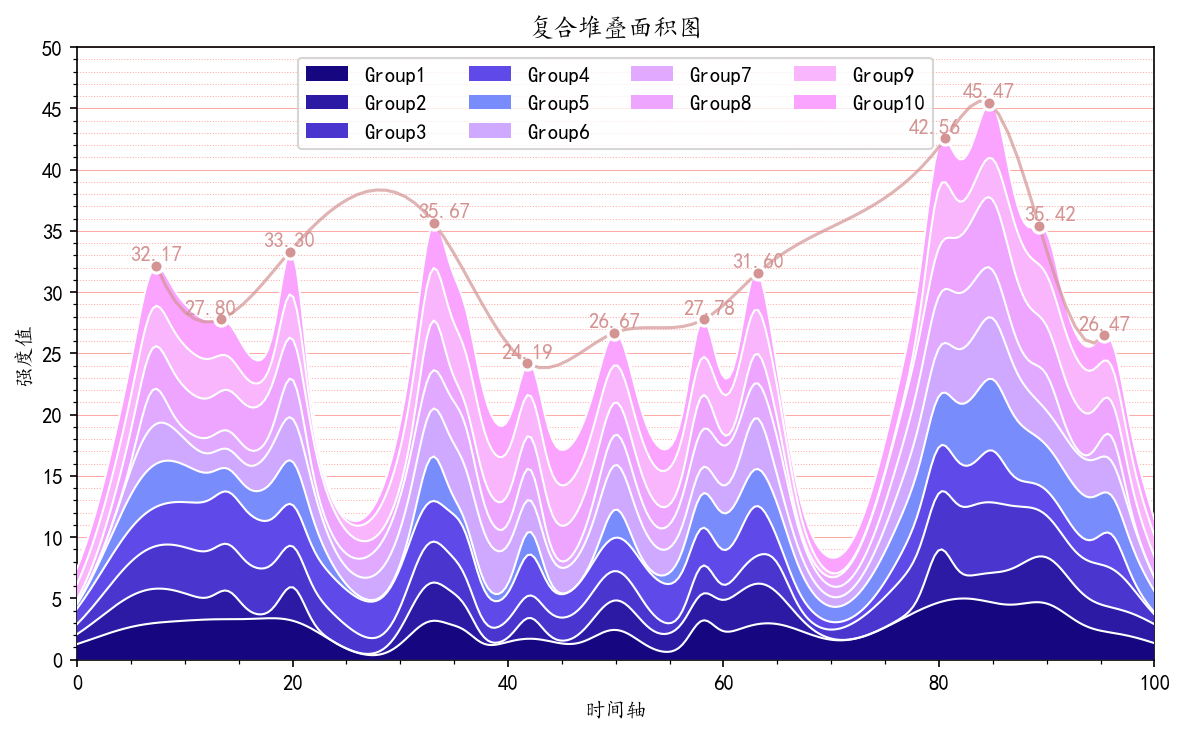

In [22]:
# ==================== 导入模块 ====================
import matplotlib.pyplot as plt  # 基础绘图库
import numpy as np  # 数值计算库
import matplotlib.ticker as ticker  # 坐标轴刻度格式化
from scipy.interpolate import make_interp_spline  # 平滑曲线插值
import random  # 随机数生成
from scipy.signal import find_peaks  # 峰值检测
import matplotlib.font_manager as fm  # 字体管理

# ==================== 样式配置模块 ====================
def initialize_plot_style(font_path):
    """初始化绘图字体设置
    参数:
        font_path: 字体文件路径(.ttf)
    功能:
        1. 加载指定中文字体
        2. 设置减号显示兼容
        3. 配置网格线颜色
    """
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = font_prop.get_name()  # 全局字体
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    plt.rcParams["grid.color"] = "#ffaba5"  # 设置网格线颜色

# ==================== 数据生成模块 ====================
def generate_gaussian_curve(x_values, peak_pos, magnitude):
    """生成单个高斯曲线数据
    参数:
        x_values: x轴坐标数组
        peak_pos: 波峰位置
        magnitude: 波峰高度
    返回:
        高斯曲线y值数组
    算法:
        y = magnitude * e^(-0.5*((x-peak_pos)/sigma)^2)
        sigma通过随机数动态生成(1/90到5/90倍x范围)
    """
    sigma = np.max(x_values) * np.random.randint(1, 6) / 90 
    return magnitude * np.exp(-0.5 * ((x_values - peak_pos) / sigma) ** 2)

def create_composite_data(num_categories, x_range, count, peaks_config):
    """生成复合堆叠数据
    参数:
        num_categories: 数据分组数量
        x_range: x轴最大值
        count: 数据点数量
        peaks_config: 峰值配置列表[(position,magnitude),...]
    返回:
        x: x轴坐标数组
        category_data: 各分组数据列表[array1, array2,...]
    流程:
        1. 生成线性空间x轴
        2. 为每个分组叠加多个高斯曲线
    """
    x = np.linspace(0, x_range, count)
    category_data = []
    
    for category in range(num_categories):
        composite_signal = np.zeros_like(x)
        for peak_pos, magnitude in peaks_config:
            composite_signal += generate_gaussian_curve(x, peak_pos, magnitude)
        category_data.append(composite_signal)
    
    return x, category_data

# ==================== 绘图模块 ====================
def render_stacked_chart(ax, x_data, category_data, colors):
    """绘制基础堆叠面积图
    参数:
        ax: matplotlib坐标轴对象
        x_data: x轴数据
        category_data: 各层数据列表
        colors: 颜色列表
    效果:
        在ax上绘制堆叠面积图，zorder=10确保在网格上方
    """
    ax.stackplot(x_data, category_data, 
                colors=colors,
                zorder=10,
                alpha=1)

def add_dividers(ax, x_data, cumulative_data):
    """添加区域分隔线
    参数:
        cumulative_data: 累积和后的数据(用于获取各层边界)
    效果:
        在每层顶部绘制白色边界线(zorder=20)
    """
    for y_series in cumulative_data:
        ax.plot(x_data, y_series, 
               color="#ffffff",
               zorder=20,
               linewidth=1)

def highlight_peaks(ax, x_data, final_series):
    """高亮显示峰值点（平滑曲线连接版）
    参数:
        ax: matplotlib坐标轴对象
        x_data: x轴数据数组
        final_series: 最顶层数据序列
    功能:
        1. 检测数据峰值点
        2. 使用样条插值生成平滑曲线
        3. 绘制曲线+标记峰值点
    """
    # 检测峰值点
    peaks, _ = find_peaks(final_series)
    peak_x = x_data[peaks]
    peak_y = final_series[peaks]
    
    # 对峰值点进行排序（确保x轴递增）
    sort_idx = np.argsort(peak_x)
    sorted_x = peak_x[sort_idx]
    sorted_y = peak_y[sort_idx]
    
    # 生成平滑曲线（使用3次样条插值）
    if len(sorted_x) > 3:  # 至少需要4个点才能插值
        spline = make_interp_spline(sorted_x, sorted_y, k=3)
        x_smooth = np.linspace(sorted_x.min(), sorted_x.max(), 100)
        y_smooth = spline(x_smooth)
        
        # 绘制平滑曲线
        ax.plot(x_smooth, y_smooth,
               color="#d49494",
               zorder=20,
               linewidth=1.5,
               linestyle="-",
               alpha=0.7)
    
    # 绘制峰值点标记
    ax.scatter(peak_x, peak_y,
              color="#d49494",
              edgecolors="#ffffff",
              zorder=30,
              s=40,  # 标记大小
              linewidths=1.5)

def annotate_peaks(ax, x_data, final_series, labels):
    """添加峰值数据标签
    参数:
        labels: 颜色列表(用于标签颜色)
    特点:
        使用x_offsets循环偏移避免标签重叠
    """
    peaks, _ = find_peaks(final_series)
    x_offsets = [0, -1, 0, 1, 0, 0, 0.5]  # 标签位置偏移模式
    
    for i, peak in enumerate(peaks):
        ax.text(x_data[peak] + x_offsets[i % len(x_offsets)],
               final_series[peak] + 0.2,
               f"{final_series[peak]:.2f}",
               ha="center",
               va="bottom",
               color="#d49494",
               zorder=30,
               fontweight="bold")

def configure_axes(ax, title, xlabel, ylabel, xlim, ylim):
    """配置坐标轴样式
    参数包含标题、轴标签和范围限制
    """
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

def setup_grid(ax):
    """配置网格样式
    特点:
        1. 主/次网格线不同样式
        2. y轴主刻度间隔5，次刻度间隔1
    """
    ax.minorticks_on()
    ax.grid(axis="y", which="major", linestyle="-", linewidth="0.5")
    ax.grid(axis="y", which="minor", linestyle=":", linewidth="0.5")
    ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))

# ==================== 主执行流程 ====================
if __name__ == "__main__":
    # 初始化配置
    FONT_PATH = r'../simkai.ttf'  # 楷体字体文件
    initialize_plot_style(FONT_PATH)
    
    # 数据配置
    PEAKS_CONFIG = [  # 峰值位置和幅度配置
        (7, 2.8), (14, 1.5), (20, 2.7), (33, 3.1), 
        (36, 0.8), (42, 1.7), (50, 2.3), (58, 2.0), 
        (63, 2.0), (65, 1.0), (80, 3.6), (85, 2.0), 
        (90, 2.0), (96, 2.0)
    ]
    COLORS = [  # 渐变色系(深蓝到粉紫)
        "#160680", "#2C1AA4", "#4A35CE", "#5F4AE9",
        "#798CFC", "#cfa8ff", "#e1a9ff", "#eda5ff", "#f9b6fc", "#faa3ff"
    ]
    
    # 生成数据(10个分组，x范围0-100，300个数据点)
    x_values, category_data = create_composite_data(
        num_categories=10,
        x_range=100,
        count=300,
        peaks_config=PEAKS_CONFIG
    )
    
    # 创建图表(8x5英寸，150dpi)
    fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
    
    # 绘制元素
    render_stacked_chart(ax, x_values, category_data, COLORS)  # 堆叠图
    cumulative_data = np.cumsum(category_data, axis=0)  # 计算累积和
    add_dividers(ax, x_values, cumulative_data)  # 添加分隔线
    highlight_peaks(ax, x_values, cumulative_data[-1])  # 标记峰值
    annotate_peaks(ax, x_values, cumulative_data[-1], COLORS)  # 峰值标注
    
    # 配置样式
    configure_axes(ax, 
                 title="复合堆叠面积图",
                 xlabel="时间轴",
                 ylabel="强度值",
                 xlim=(0, 100),
                 ylim=(0, 50))
    
    setup_grid(ax)  # 网格设置
    ax.legend(labels=[f"Group{i+1}" for i in range(10)],
             loc="upper center",
             ncol=4,
             prop={"weight": "bold"})  # 图例设置
    
    plt.tight_layout()  # 自动调整布局
    plt.savefig('group_stack_area_graph.png', dpi=400, bbox_inches='tight') # 保存图片
    plt.show()

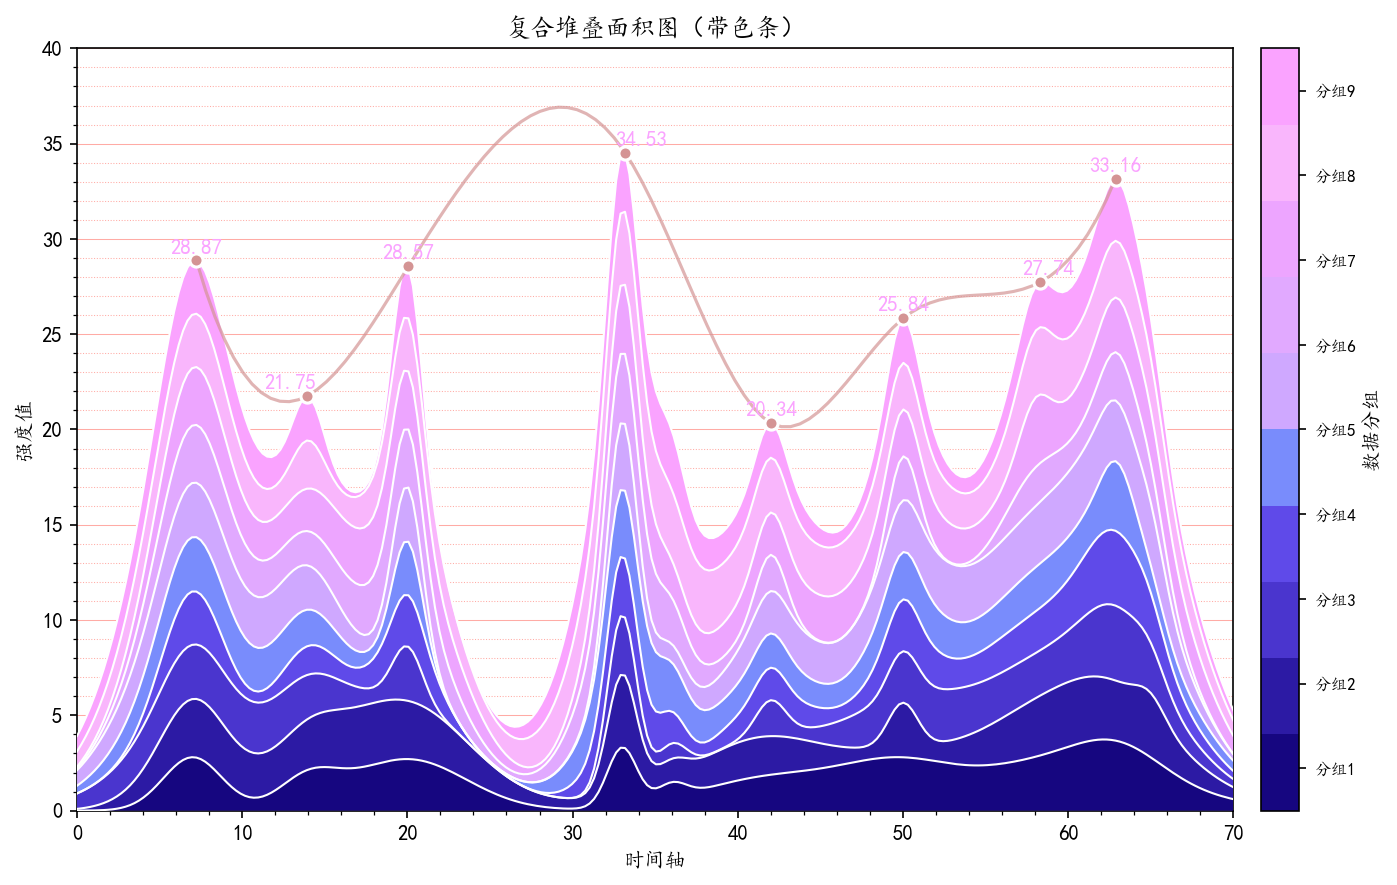

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from scipy.interpolate import make_interp_spline
import random
from scipy.signal import find_peaks
import matplotlib.font_manager as fm
from matplotlib import cm  # 新增：导入colormap模块
 
# 样式配置模块
def initialize_plot_style(font_path):
    """初始化绘图字体设置"""
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = font_prop.get_name()
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams["grid.color"] = "#ffaba5"
 
# 数据生成模块
def generate_gaussian_curve(x_values, peak_pos, magnitude):
    """生成单个高斯曲线数据"""
    sigma = np.max(x_values) * np.random.randint(1, 6) / 90 
    return magnitude * np.exp(-0.5 * ((x_values - peak_pos) / sigma) ** 2)
 
def create_composite_data(num_categories, x_range, peaks_config):
    """生成复合堆叠数据"""
    x = np.linspace(0, x_range, 300)
    category_data = []
    
    for category in range(num_categories):
        composite_signal = np.zeros_like(x)
        for peak_pos, magnitude in peaks_config:
            composite_signal += generate_gaussian_curve(x, peak_pos, magnitude)
        category_data.append(composite_signal)
    
    return x, category_data
 
# 绘图模块
def render_stacked_chart(ax, x_data, category_data, colors):
    """绘制基础堆叠面积图"""
    # 修改：返回stackplot对象用于色条
    return ax.stackplot(x_data, category_data, 
                      colors=colors,
                      zorder=10,
                      alpha=1)
 
def add_dividers(ax, x_data, cumulative_data):
    """添加区域分隔线"""
    for y_series in cumulative_data:
        ax.plot(x_data, y_series, 
               color="#ffffff",
               zorder=20,
               linewidth=1)
 

def highlight_peaks(ax, x_data, final_series):
    """高亮显示峰值点（平滑曲线连接版）
    参数:
        ax: matplotlib坐标轴对象
        x_data: x轴数据数组
        final_series: 最顶层数据序列
    功能:
        1. 检测数据峰值点
        2. 使用样条插值生成平滑曲线
        3. 绘制曲线+标记峰值点
    """
    # 检测峰值点
    peaks, _ = find_peaks(final_series)
    peak_x = x_data[peaks]
    peak_y = final_series[peaks]
    
    # 对峰值点进行排序（确保x轴递增）
    sort_idx = np.argsort(peak_x)
    sorted_x = peak_x[sort_idx]
    sorted_y = peak_y[sort_idx]
    
    # 生成平滑曲线（使用3次样条插值）
    if len(sorted_x) > 3:  # 至少需要4个点才能插值
        spline = make_interp_spline(sorted_x, sorted_y, k=3)
        x_smooth = np.linspace(sorted_x.min(), sorted_x.max(), 100)
        y_smooth = spline(x_smooth)
        
        # 绘制平滑曲线
        ax.plot(x_smooth, y_smooth,
               color="#d49494",
               zorder=20,
               linewidth=1.5,
               linestyle="-",
               alpha=0.7)
    
    # 绘制峰值点标记
    ax.scatter(peak_x, peak_y,
              color="#d49494",
              edgecolors="#ffffff",
              zorder=30,
              s=40,  # 标记大小
              linewidths=1.5)
 
def annotate_peaks(ax, x_data, final_series, labels):
    """添加峰值数据标签"""
    peaks, _ = find_peaks(final_series)
    x_offsets = [0, -1, 0, 1, 0, 0, 0.5]
    
    for i, peak in enumerate(peaks):
        ax.text(x_data[peak] + x_offsets[i % len(x_offsets)],
               final_series[peak] + 0.2,
               f"{final_series[peak]:.2f}",
               ha="center",
               va="bottom",
               color=COLORS[-1],
               zorder=30,
               fontweight="bold")

def add_colorbar(fig, ax, stacked_plot, colors):
    """添加色条"""
    # 创建自定义colormap
    cmap = cm.colors.ListedColormap(colors)
    norm = cm.colors.Normalize(vmin=0, vmax=len(colors)-1)
    
    # 添加色条
    cbar = fig.colorbar(
        cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=ax,
        orientation='vertical',
        pad=0.02,
        ticks=np.arange(len(colors))+0.5
    )
    
    # 设置色条标签
    cbar.ax.set_yticklabels([f'分组{i+1}' for i in range(len(colors))])
    cbar.set_label('数据分组', fontweight='bold')
    cbar.ax.tick_params(labelsize=8)
 
def configure_axes(ax, title, xlabel, ylabel, xlim, ylim):
    """配置坐标轴样式"""
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
 
def setup_grid(ax):
    """配置网格样式"""
    ax.minorticks_on()
    ax.grid(axis="y", which="major", linestyle="-", linewidth="0.5")
    ax.grid(axis="y", which="minor", linestyle=":", linewidth="0.5")
    ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
 
# 主执行流程
if __name__ == "__main__":
    # 初始化配置
    FONT_PATH = r'../simkai.ttf'
    initialize_plot_style(FONT_PATH)
    
    # 数据配置
    PEAKS_CONFIG = [
        (7, 2.8), (14, 1.5), (20, 2.7), (33, 3.1), 
        (36, 0.8), (42, 1.7), (50, 2.3), (58, 2.0), (63, 2.0), (65, 1.0)
    ]
    COLORS = [  # 渐变色系(深蓝到粉紫)
        "#160680", "#2C1AA4", "#4A35CE", "#5F4AE9",
        "#798CFC", "#cfa8ff", "#e1a9ff", "#eda5ff", "#f9b6fc", "#faa3ff"
    ]
    # 生成数据
    x_values, category_data = create_composite_data(
        num_categories=10,
        x_range=80,
        peaks_config=PEAKS_CONFIG
    )
    
    # 创建图表
    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)  # 增大画布尺寸
    
    # 绘制元素
    stacked_plot = render_stacked_chart(ax, x_values, category_data, COLORS)
    cumulative_data = np.cumsum(category_data, axis=0)
    add_dividers(ax, x_values, cumulative_data)
    highlight_peaks(ax, x_values, cumulative_data[-1])
    annotate_peaks(ax, x_values, cumulative_data[-1], COLORS)
    
    # 配置样式
    configure_axes(ax, 
                 title="复合堆叠面积图（带色条）",
                 xlabel="时间轴",
                 ylabel="强度值",
                 xlim=(0, 70),
                 ylim=(0, 40))
    
    setup_grid(ax)
    
    # 添加色条（替代原有图例）
    add_colorbar(fig, ax, stacked_plot, COLORS)
    
    plt.tight_layout()
    plt.savefig('stacked_plot_with_colorbar.png', dpi=300, bbox_inches='tight')
    plt.show()